<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/14.Chapter14%3ASVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 14: Singular Value Decomposition

## From *Practical Linear Algebra for Data Science* by Mike X Cohen

---

The **Singular Value Decomposition (SVD)** is arguably the single most important matrix decomposition in all of applied mathematics. It takes *any* matrix -- square or rectangular, full-rank or singular, real or complex -- and decomposes it into three matrices that reveal everything about its structure.

$$\boxed{\mathbf{A} = \mathbf{U} \boldsymbol{\Sigma} \mathbf{V}^T}$$

If eigendecomposition (Chapter 13) is a pearl of linear algebra, then the SVD is the entire treasure chest. Here is what the SVD reveals:

- **Column space and left-null space** -- from $\mathbf{U}$
- **Row space and null space** -- from $\mathbf{V}$
- **Rank** -- number of nonzero singular values
- **Numerical stability** -- condition number $\kappa = \sigma_{\max}/\sigma_{\min}$
- **Best low-rank approximation** -- truncating small singular values
- **Pseudoinverse** -- inverting the nonzero singular values

You can think of the SVD as a **generalization of eigendecomposition** to non-square matrices -- or eigendecomposition as a special case of SVD for square symmetric matrices.

**Prerequisites:** Eigendecomposition (Chapter 13), matrix rank (Chapter 6), the four subspaces (Chapter 4), orthogonal matrices (Chapter 7).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print('Libraries loaded.')
print(f'NumPy version: {np.__version__}')

Libraries loaded.
NumPy version: 2.0.2


---
## The Big Picture of the SVD

The SVD decomposes an $M \times N$ matrix $\mathbf{A}$ into three factors:

$$\mathbf{A}_{M \times N} = \underbrace{\mathbf{U}}_{M \times M} \;\; \underbrace{\boldsymbol{\Sigma}}_{M \times N} \;\; \underbrace{\mathbf{V}^T}_{N \times N}$$

**$\mathbf{U}$ (left singular vectors):** $M \times M$ **orthogonal** matrix. The first $r$ columns span the **column space**; the remaining $M - r$ span the **left-null space**.

**$\boldsymbol{\Sigma}$ (singular values):** $M \times N$ diagonal matrix with entries $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$. Always **real and non-negative**.

**$\mathbf{V}^T$ (right singular vectors):** $N \times N$ orthogonal matrix. The first $r$ rows (columns of $\mathbf{V}$) span the **row space**; the remaining span the **null space**.

The SVD reveals **all four fundamental subspaces** simultaneously -- the only decomposition that does so.

### Why the SVD Is So Important

Many matrix decompositions exist (LU, QR, Cholesky, eigendecomposition). What makes the SVD uniquely valuable?

**1. Universality:** The SVD exists for *every* matrix -- any size, any rank, real or complex. No other factorization is this general.

**2. Optimality:** The rank-$k$ truncation gives the *best possible* rank-$k$ approximation (Eckart-Young theorem). No other method can do better.

**3. Stability:** Because $\mathbf{U}$ and $\mathbf{V}$ are orthogonal (condition number $= 1$), the SVD amplifies no errors.

**4. Completeness:** One decomposition reveals all four subspaces, the rank, the condition number, and provides the pseudoinverse.

**5. Interpretability:** Singular values have direct physical meaning (importance, variance, energy). The rank-$1$ layer interpretation makes the decomposition intuitive.

In [ ]:
A = np.array([[1, 2, 0],
              [0, 1, 1],
              [1, 0, 1],
              [0, 1, 0]])
print(f"Matrix A ({A.shape[0]}x{A.shape[1]}):")
print(A)
print(f"Rank: {np.linalg.matrix_rank(A)}")

U, s, Vt = np.linalg.svd(A)
Sigma = np.zeros(A.shape)
np.fill_diagonal(Sigma, s)

print(f"\nU ({U.shape[0]}x{U.shape[1]}):")
print(U.round(4))
print(f"\nSigma ({Sigma.shape[0]}x{Sigma.shape[1]}):")
print(Sigma.round(4))
print(f"\nV^T ({Vt.shape[0]}x{Vt.shape[1]}):")
print(Vt.round(4))
print(f"\nSingular values: {s.round(4)}")
print(f"Reconstruction matches? {np.allclose(A, U @ Sigma @ Vt)}")

Matrix A (4x3):
[[1 2 0]
 [0 1 1]
 [1 0 1]
 [0 1 0]]
Rank: 3

U (4x4):
[[-0.8086  0.2887 -0.4237 -0.2887]
 [-0.4237 -0.2887  0.8086 -0.2887]
 [-0.2387 -0.866  -0.3312  0.2887]
 [-0.3312  0.2887  0.2387  0.866 ]]

Sigma (4x3):
[[2.6762 0.     0.    ]
 [0.     1.4142 0.    ]
 [0.     0.     0.9153]
 [0.     0.     0.    ]]

V^T (3x3):
[[-0.3913 -0.8863 -0.2475]
 [-0.4082  0.4082 -0.8165]
 [-0.8247  0.2185  0.5216]]

Singular values: [2.6762 1.4142 0.9153]
Reconstruction matches? True


### Anatomy of the SVD

Our $4 \times 3$ matrix has rank $3$ and $3$ nonzero singular values: $\sigma_1 = 2.6762$, $\sigma_2 = 1.4142$, $\sigma_3 = 0.9153$.

The dimensions: $\mathbf{U}$ is $4 \times 4$, $\boldsymbol{\Sigma}$ is $4 \times 3$ (same as $\mathbf{A}$), $\mathbf{V}^T$ is $3 \times 3$. The product $(4{\times}4)(4{\times}3)(3{\times}3) = 4{\times}3$ recovers $\mathbf{A}$.

**NumPy convention:** `np.linalg.svd` returns singular values as a **1D vector**, not a matrix. You must build $\boldsymbol{\Sigma}$ yourself by creating a zero matrix of $\mathbf{A}$'s shape and filling its diagonal. Also, NumPy returns $\mathbf{V}^T$, **not** $\mathbf{V}$. Right singular vectors are the **rows** of the output.

In [ ]:
print("--- Orthogonality ---")
print(f"U^T U = I? {np.allclose(U.T @ U, np.eye(4))}")
print(f"V^T V = I? {np.allclose(Vt @ Vt.T, np.eye(3))}")
print(f"\n--- Singular values ---")
print(f"All non-negative? {np.all(s >= 0)}")
print(f"Sorted descending? {np.all(np.diff(s) <= 1e-10)}")
print(f"\n--- Four subspaces (rank r = {np.linalg.matrix_rank(A)}) ---")
r = np.linalg.matrix_rank(A)
print(f"Column space:    first {r} cols of U")
print(f"Left-null space: last {A.shape[0]-r} col(s) of U")
print(f"Row space:       first {r} cols of V (rows of V^T)")
print(f"Null space:      last {A.shape[1]-r} col(s) of V")

# Verify left-null space
for i in range(r, A.shape[0]):
    prod = A.T @ U[:, i]
    print(f"\nA^T @ U[:,{i}] = {prod.round(10)} (should be zero)")

--- Orthogonality ---
U^T U = I? True
V^T V = I? True

--- Singular values ---
All non-negative? True
Sorted descending? True

--- Four subspaces (rank r = 3) ---
Column space:    first 3 cols of U
Left-null space: last 1 col(s) of U
Row space:       first 3 cols of V (rows of V^T)
Null space:      last 0 col(s) of V

A^T @ U[:,3] = [0. 0. 0.] (should be zero)


### Why These Properties Matter

**Orthogonality** ($\mathbf{U}^T\mathbf{U} = \mathbf{I}$ and $\mathbf{V}^T\mathbf{V} = \mathbf{I}$) has deep practical consequences. First, $\mathbf{U}^{-1} = \mathbf{U}^T$ -- inversion is free (just transpose). Second, orthogonal matrices preserve norms: $\|\mathbf{U}\mathbf{x}\| = \|\mathbf{x}\|$ for any $\mathbf{x}$. SVD factors do not distort geometry -- they only rotate.

**Non-negative, sorted singular values** provide a natural importance ranking. The largest captures the most "energy"; the smallest the least. Unlike eigenvalues (which can be negative or complex), singular values are always real and non-negative -- directly interpretable as magnitudes.

**All four subspaces** are revealed by one decomposition. The rank $r$ divides column/row spaces (first $r$ singular vectors) from null/left-null spaces (remaining). This makes the abstract subspaces from Chapter 4 concrete and computable.

**Connection to Chapter 13:** The SVD inherits its properties from eigendecomposition of symmetric matrices ($\mathbf{A}^T\mathbf{A}$ and $\mathbf{A}\mathbf{A}^T$). Orthogonality comes from symmetric eigenvectors being orthogonal. Non-negativity comes from $\mathbf{A}^T\mathbf{A}$ being positive semidefinite.

In [ ]:
np.random.seed(42)
shapes = {"Tall (5x3)": (5,3), "Wide (3x5)": (3,5), "Square (4x4)": (4,4),
          "Row (1x5)": (1,5), "Col (5x1)": (5,1)}
print(f"{'Name':<14} {'A':>8} {'U':>8} {'|s|':>5} {'Vt':>8} {'Rank':>5}")
print('='*50)
for nm, sh in shapes.items():
    Am = np.random.randn(*sh)
    Um, sm, Vm = np.linalg.svd(Am)
    print(f"{nm:<14} {str(sh):>8} {str(Um.shape):>8} {len(sm):>5} {str(Vm.shape):>8} {np.linalg.matrix_rank(Am):>5}")
print("\nU is always MxM, V^T always NxN, |s| = min(M,N).")

Name                  A        U   |s|       Vt  Rank
Tall (5x3)       (5, 3)   (5, 5)     3   (3, 3)     3
Wide (3x5)       (3, 5)   (3, 3)     3   (5, 5)     3
Square (4x4)     (4, 4)   (4, 4)     4   (4, 4)     4
Row (1x5)        (1, 5)   (1, 1)     1   (5, 5)     1
Col (5x1)        (5, 1)   (5, 5)     1   (1, 1)     1

U is always MxM, V^T always NxN, |s| = min(M,N).


### SVD Works for Everything -- Even Vectors

Unlike eigendecomposition (which requires square matrices), the SVD handles any shape -- tall, wide, square, even single row or column vectors. This universality is a key advantage.

**The economy SVD:** When $M \gg N$, the full $\mathbf{U}$ is enormous and mostly irrelevant. Use `np.linalg.svd(A, full_matrices=False)` to get the "thin" SVD: only the first $\min(M,N)$ columns of $\mathbf{U}$ and rows of $\mathbf{V}^T$. Faster, less memory, and avoids the Sigma-construction pitfall.

**Practical guideline:** Use the economy SVD for computation (regression, PCA, compression). Use the full SVD only when you need explicit null space or left-null space vectors.

### The Vector-Level SVD Equations

The matrix equation $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$ can be written at the vector level:

$$\mathbf{A}\mathbf{v}_i = \sigma_i \, \mathbf{u}_i \qquad \text{and} \qquad \mathbf{u}_i^T \mathbf{A} = \sigma_i \, \mathbf{v}_i^T$$

Compare with the eigenvalue equation $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$: in the eigenvalue case, the input and output vectors are the *same*; in the SVD, the input ($\mathbf{v}_i$) and output ($\mathbf{u}_i$) are *different* vectors in *different* spaces.

**Interpretation:** $\mathbf{A}$ maps from the row space (spanned by $\mathbf{v}_i$) to the column space (spanned by $\mathbf{u}_i$), with each direction scaled by $\sigma_i$. The SVD reveals the complete geometry of this mapping: which input directions get mapped where, and by how much.

---
## Singular Values and Matrix Rank

The rank of a matrix equals the number of **nonzero** singular values. In practice, NumPy uses a tolerance threshold to distinguish genuine zeros from rounding errors:

$$\text{tol} = \sigma_{\max} \times \max(M, N) \times \epsilon \qquad (\epsilon \approx 2.2 \times 10^{-16})$$

In [ ]:
np.random.seed(42)
col1 = np.random.randn(5); col2 = np.random.randn(5)
A_r2 = np.column_stack([col1, col2, 2*col1 - col2, col1 + 3*col2])
A_r1 = np.outer([1,2,3,4], [5,6,7])
A_full = np.random.randn(4, 4)

for nm, Am in [("Full rank 4x4", A_full), ("Rank-2 (5x4)", A_r2), ("Rank-1 (4x3)", A_r1)]:
    sv = np.linalg.svd(Am, compute_uv=False)
    print(f"{nm}: sigma = {sv.round(6)}, rank = {np.linalg.matrix_rank(Am)}")

print("\n--- How matrix_rank works ---")
sv_demo = np.linalg.svd(A_r2, compute_uv=False)
tol = sv_demo.max() * max(A_r2.shape) * np.finfo(float).eps
print(f"sigma = {sv_demo.round(12)}")
print(f"tol = {tol:.2e}")
print(f"Values > tol: {np.sum(sv_demo > tol)} = rank")

Full rank 4x4: sigma = [2.6826 2.1263 1.6285 1.2485], rank = 4
Rank-2 (5x4): sigma = [6.2915 4.1944 0.     0.    ], rank = 2
Rank-1 (4x3): sigma = [57.4456  0.      0.    ], rank = 1

--- How matrix_rank works ---
sigma = [6.2915 4.1944 0.     0.    ]
tol = 6.98e-15
Values > tol: 2 = rank


### Rank via SVD -- Theory vs. Practice

In theory, rank = number of *exactly* nonzero singular values. In practice, rounding errors create values like $10^{-16}$ where zeros should be. NumPy uses a tolerance:

$$\text{tol} = \sigma_{\max} \times \max(M, N) \times \epsilon \qquad (\epsilon \approx 2.2 \times 10^{-16} \text{ for float64})$$

Values below this threshold are treated as zero. The formula balances two risks: inflating rank (rounding errors mistaken as nonzero) vs. underestimating it (small genuine values treated as zero).

In the rank-$2$ example, two singular values are substantial and two are at machine precision -- correctly identified as zero. If the near-zero values were $10^{-8}$ instead, we would face a harder question: genuine or artifact? This ambiguity is inherent in numerical linear algebra.

---
## SVD in Python: Full vs. Economy

| | Full SVD | Economy SVD |
|:---|:---|:---|
| Call | `svd(A)` | `svd(A, full_matrices=False)` |
| $\mathbf{U}$ | $M \times M$ | $M \times \min(M,N)$ |
| $\mathbf{V}^T$ | $N \times N$ | $\min(M,N) \times N$ |
| $\boldsymbol{\Sigma}$ | Need `zeros` + `fill_diagonal` | `np.diag(s)` works |
| Null spaces? | Yes | No |

In [ ]:
A = np.array([[3, 2, 2],
              [2, 3, -2]])
U, s, Vt = np.linalg.svd(A)
print(f"Full SVD: U {U.shape}, s {s.shape}, Vt {Vt.shape}")
print(f"WRONG: np.diag(s) shape = {np.diag(s).shape} (not {A.shape}!)")

Sigma = np.zeros(A.shape); np.fill_diagonal(Sigma, s)
print(f"RIGHT: zeros+fill shape = {Sigma.shape}")
print(f"Reconstructs? {np.allclose(A, U @ Sigma @ Vt)}")

Ue, se, Ve = np.linalg.svd(A, full_matrices=False)
print(f"\nEconomy SVD: U {Ue.shape}, s {se.shape}, Vt {Ve.shape}")
print(f"np.diag(s) shape = {np.diag(se).shape} (correct!)")
print(f"Reconstructs? {np.allclose(A, Ue @ np.diag(se) @ Ve)}")

Full SVD: U (2, 2), s (2,), Vt (3, 3)
WRONG: np.diag(s) shape = (2, 2) (not (2, 3)!)
RIGHT: zeros+fill shape = (2, 3)
Reconstructs? True

Economy SVD: U (2, 2), s (2,), Vt (2, 3)
np.diag(s) shape = (2, 2) (correct!)
Reconstructs? True


### Avoiding the Sigma Pitfall

For a $2 \times 3$ matrix, `np.diag(s)` produces a $2 \times 2$ matrix -- wrong shape! The full SVD requires `np.zeros(A.shape)` + `np.fill_diagonal`. The economy SVD avoids this issue because $\boldsymbol{\Sigma}$ is square ($\min(M,N) \times \min(M,N)$).

The economy SVD is preferred for most practical work -- it is faster, uses less memory, and sidesteps dimension mismatches. Use the full SVD only when you need the null space or left-null space vectors.

---
## SVD and Rank-1 "Layers"

The SVD expresses $\mathbf{A}$ as a sum of rank-$1$ outer products:

$$\mathbf{A} = \sum_{i=1}^{r} \sigma_i \, \mathbf{u}_i \mathbf{v}_i^T$$

Each layer $\sigma_i \mathbf{u}_i \mathbf{v}_i^T$ is a rank-$1$ matrix whose Frobenius norm equals $\sigma_i$ (because $\|\mathbf{u}\| = \|\mathbf{v}\| = 1$). The layers are ordered by importance: the first captures the dominant pattern.

Keeping only $k < r$ layers gives the **best rank-$k$ approximation** (Eckart-Young theorem).

Matrix A (rank 3), sigma = [2.6762 1.4142 0.9153]

Layer 1: sigma=2.6762, ||layer||_F=2.6762
Layer 2: sigma=1.4142, ||layer||_F=1.4142
Layer 3: sigma=0.9153, ||layer||_F=0.9153


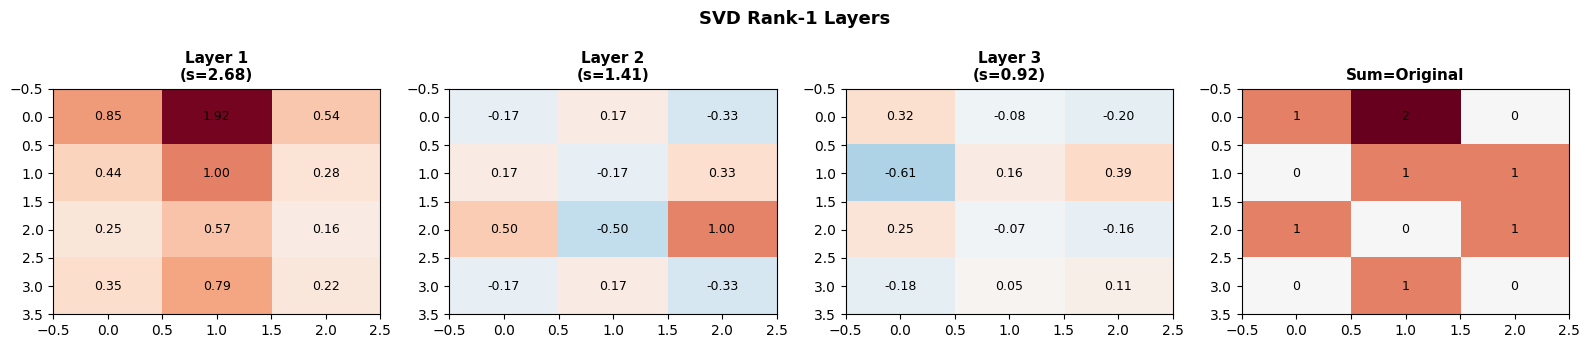


Sum of layers = A? True


In [ ]:
A = np.array([[1,2,0],[0,1,1],[1,0,1],[0,1,0]])
U, s, Vt = np.linalg.svd(A, full_matrices=False)
r = np.linalg.matrix_rank(A)
print(f"Matrix A (rank {r}), sigma = {s.round(4)}\n")

fig, axes = plt.subplots(1, r+1, figsize=(4*(r+1), 3.5))
cum = np.zeros_like(A, dtype=float)
for i in range(r):
    layer = s[i] * np.outer(U[:,i], Vt[i,:])
    cum += layer
    print(f"Layer {i+1}: sigma={s[i]:.4f}, ||layer||_F={np.linalg.norm(layer,'fro'):.4f}")
    ax = axes[i]
    ax.imshow(layer, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
    ax.set_title(f'Layer {i+1}\n(s={s[i]:.2f})', fontsize=11, fontweight='bold')
    for row in range(4):
        for col in range(3):
            ax.text(col, row, f'{layer[row,col]:.2f}', ha='center', va='center', fontsize=9)

axes[r].imshow(A.astype(float), cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
axes[r].set_title('Sum=Original', fontsize=11, fontweight='bold')
for row in range(4):
    for col in range(3):
        axes[r].text(col, row, f'{A[row,col]:.0f}', ha='center', va='center', fontsize=9)
plt.suptitle('SVD Rank-1 Layers', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"\nSum of layers = A? {np.allclose(cum, A)}")

### Understanding the Layers

Each layer's Frobenius norm exactly equals its singular value: $\|\sigma_i \mathbf{u}_i\mathbf{v}_i^T\|_F = \sigma_i$ (because $\|\mathbf{u}_i\| = \|\mathbf{v}_i\| = 1$). The singular values directly quantify each layer's importance.

Layer 1 captures the dominant pattern; subsequent layers add refinement. For **low-rank approximation**, keeping only the first $k$ layers:

$$\widetilde{\mathbf{A}}_k = \sum_{i=1}^{k} \sigma_i \, \mathbf{u}_i \mathbf{v}_i^T$$

The **Eckart-Young theorem** guarantees this is the closest rank-$k$ matrix to $\mathbf{A}$ in both the Frobenius and spectral norms. No other rank-$k$ matrix can do better.

**Storage savings:** The full matrix requires $M \times N$ numbers. A rank-$k$ approximation stores $k(M + N + 1)$ numbers. When $k \ll \min(M, N)$, this is dramatic compression. For a $1000 \times 1000$ matrix with $k = 10$: $20{,}010$ instead of $1{,}000{,}000$ -- a $50\times$ reduction.

**Applications (Chapter 15):** Low-rank approximation is the foundation for data compression (keep important layers) and denoising (noise spreads across many layers with small singular values; removing them cleans the signal).

### Geometric Interpretation: Rotate, Stretch, Rotate

The SVD tells us that *any* linear transformation decomposes into three steps:

$$\mathbf{A} = \underbrace{\mathbf{U}}_{\text{rotate output}} \;\; \underbrace{\boldsymbol{\Sigma}}_{\text{stretch}} \;\; \underbrace{\mathbf{V}^T}_{\text{rotate input}}$$

First, $\mathbf{V}^T$ rotates the input to align with the "natural axes" of $\mathbf{A}$. Then $\boldsymbol{\Sigma}$ stretches along each axis by $\sigma_i$. Finally, $\mathbf{U}$ rotates into the output space.

This explains why a unit sphere in input space becomes an **ellipsoid** in output space: the semi-axes of the ellipsoid are the singular values $\sigma_i$, and the directions of the semi-axes are the left singular vectors $\mathbf{u}_i$.

**Think of squeezing a rubber ball:** You rotate it into your grip ($\mathbf{V}^T$), squeeze along certain axes ($\boldsymbol{\Sigma}$), then rotate the deformed ball to its final position ($\mathbf{U}$). The singular values tell you *how much* each axis is stretched.

---
## SVD from Eigendecomposition

The SVD factors come from eigendecomposing the matrix times its transpose:

$$\mathbf{A}\mathbf{A}^T = \mathbf{U}\boldsymbol{\Sigma}^2\mathbf{U}^T \qquad \text{(left singular vectors)}$$
$$\mathbf{A}^T\mathbf{A} = \mathbf{V}\boldsymbol{\Sigma}^2\mathbf{V}^T \qquad \text{(right singular vectors)}$$

This reveals why singular values are non-negative ($\sigma_i = \sqrt{\lambda_i}$ and $\mathbf{A}^T\mathbf{A}$ is PSD), real (symmetric matrices have real eigenvalues), and singular vectors are orthogonal (eigenvectors of symmetric matrices are orthogonal).

In [ ]:
np.random.seed(42)
A = np.random.randn(4, 3)
print(f"A ({A.shape[0]}x{A.shape[1]})")

# NumPy SVD
U_svd, s_svd, Vt_svd = np.linalg.svd(A, full_matrices=False)

# From eigendecomposition of A^T A
ATA = A.T @ A
ev_R, evc_R = np.linalg.eigh(ATA)
idx = np.argsort(ev_R)[::-1]; ev_R = ev_R[idx]; evc_R = evc_R[:, idx]
s_eig = np.sqrt(np.maximum(ev_R, 0))

print(f"\nSigma from SVD:       {s_svd.round(6)}")
print(f"Sigma from sqrt(eig): {s_eig.round(6)}")
print(f"Match? {np.allclose(s_svd, s_eig)}")

# Eigenvalues of AA^T vs A^T A
AAT = A @ A.T
ev_L = np.sort(np.linalg.eigh(AAT)[0])[::-1]
print(f"\neig(AA^T)[:3]: {ev_L[:3].round(6)}")
print(f"eig(A^T A):    {ev_R.round(6)}")
print(f"Nonzero eigenvalues match? {np.allclose(sorted(ev_L[:3])[::-1], sorted(ev_R)[::-1])}")

# Shortcut: V^T = Sigma^{-1} U^T A
print(f"\nShortcut: V^T = Sigma^(-1) U^T A")
AAT_ev, AAT_evc = np.linalg.eigh(AAT)
idx_L = np.argsort(AAT_ev)[::-1]
U_eig = AAT_evc[:, idx_L[:3]]
Vt_sc = np.diag(1/s_eig) @ U_eig.T @ A
print(f"|V^T_shortcut| matches |V^T_svd|? {np.allclose(np.abs(Vt_sc), np.abs(Vt_svd))}")

A (4x3)

Sigma from SVD:       [2.3764 0.9138 0.8133]
Sigma from sqrt(eig): [2.3764 0.9138 0.8133]
Match? True

eig(AA^T)[:3]: [5.6474 0.8351 0.6614]
eig(A^T A):    [5.6474 0.8351 0.6614]
Nonzero eigenvalues match? True

Shortcut: V^T = Sigma^(-1) U^T A
|V^T_shortcut| matches |V^T_svd|? True


### The SVD-Eigendecomposition Connection

The nonzero eigenvalues of $\mathbf{A}\mathbf{A}^T$ and $\mathbf{A}^T\mathbf{A}$ are identical ($\sigma_i^2$). Their eigenvectors give $\mathbf{U}$ and $\mathbf{V}$. Once you have $\mathbf{U}$ and $\boldsymbol{\Sigma}$, compute $\mathbf{V}^T$ without a second eigendecomposition:

$$\mathbf{V}^T = \boldsymbol{\Sigma}^{-1}\mathbf{U}^T\mathbf{A}$$

This follows from rearranging $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$.

**For a $4 \times 3$ matrix:** $\mathbf{A}\mathbf{A}^T$ is $4 \times 4$ (gives $4$ eigenvalues, one zero) and $\mathbf{A}^T\mathbf{A}$ is $3 \times 3$ (gives $3$ eigenvalues). The $3$ nonzero eigenvalues match -- reflecting that column rank always equals row rank.

**Practical note:** Modern algorithms (Golub-Kahan bidiagonalization) do *not* form $\mathbf{A}\mathbf{A}^T$ explicitly because squaring doubles the condition number. But the conceptual connection explains why the SVD has its remarkable properties.

---
## SVD of Symmetric PSD Matrices = Eigendecomposition

For symmetric matrices, SVD and eigendecomposition produce the same result. $\mathbf{U} = \mathbf{V}$ (up to signs) and singular values equal eigenvalues (for PSD matrices). This is why PCA can use either decomposition interchangeably.

In [ ]:
np.random.seed(42)
R = np.random.randn(4, 4)
S = R.T @ R  # symmetric positive definite

evals, evecs = np.linalg.eigh(S)
idx = np.argsort(evals)[::-1]; evals = evals[idx]; evecs = evecs[:, idx]

U_s, s_s, Vt_s = np.linalg.svd(S)

print(f"Symmetric PSD matrix S = R^T R\n")
print(f"Eigenvalues:     {evals.round(4)}")
print(f"Singular values: {s_s.round(4)}")
print(f"Match? {np.allclose(evals, s_s)}")
print(f"\nU = V for each component?")
for i in range(4):
    print(f"  {i+1}: {np.allclose(np.abs(U_s[:,i]), np.abs(Vt_s[i,:]))}")
print("\nFor symmetric PSD matrices: SVD = eigendecomposition.")

Symmetric PSD matrix S = R^T R

Eigenvalues:     [9.4839 3.7076 0.8464 0.1167]
Singular values: [9.4839 3.7076 0.8464 0.1167]
Match? True

U = V for each component?
  1: True
  2: True
  3: True
  4: True

For symmetric PSD matrices: SVD = eigendecomposition.


### Why This Equivalence Matters

Every covariance matrix is symmetric PSD ($\mathbf{C} = \mathbf{X}^T\mathbf{X}/(n-1)$). So PCA can equivalently use `eigh(C)`, `svd(C)`, or `svd(X)` -- all give the same principal components. Chapter 15 explores this in detail.

---
## Converting Singular Values to Percent Variance

$$\tilde{\sigma}_i = 100 \times \frac{\sigma_i}{\displaystyle\sum_j \sigma_j}$$

Since singular vectors are unit-length, all magnitude information lives in $\boldsymbol{\Sigma}$. The singular vectors point; the singular values say how far.

Top 10 components:
  #      sigma     %Var     Cum%
  1    135.404    43.9%    43.9%
  2     83.600    27.1%    71.0%
  3      5.788     1.9%    72.9%
  4      5.333     1.7%    74.6%
  5      5.257     1.7%    76.3%
  6      4.870     1.6%    77.9%
  7      4.631     1.5%    79.4%
  8      4.606     1.5%    80.9%
  9      4.259     1.4%    82.3%
 10      4.146     1.3%    83.6%


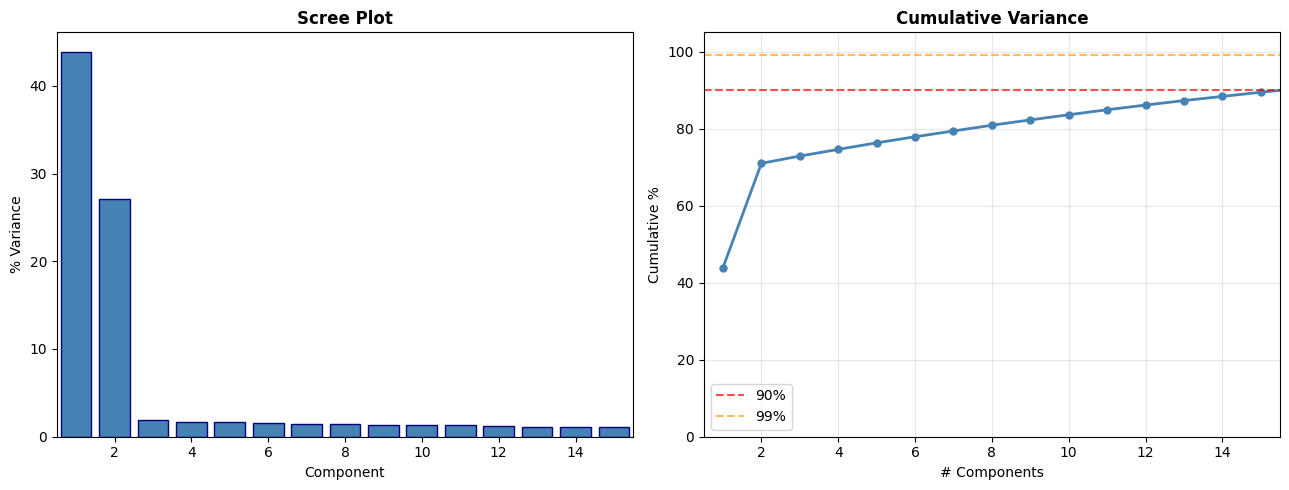


90%: 16 components, 99%: 28 components (of 30)


In [ ]:
np.random.seed(42)
m, n = 50, 30
p1 = np.outer(np.sin(np.linspace(0, 2*np.pi, m)), np.ones(n))
p2 = np.outer(np.ones(m), np.cos(np.linspace(0, np.pi, n)))
p3 = np.outer(np.linspace(-1, 1, m), np.linspace(1, -1, n))
X = 5*p1 + 3*p2 + 1*p3 + 0.5*np.random.randn(m, n)

sv = np.linalg.svd(X, compute_uv=False)
pct = 100 * sv / sv.sum()
cum = np.cumsum(pct)

print(f"Top 10 components:")
print(f"{'#':>3} {'sigma':>10} {'%Var':>8} {'Cum%':>8}")
for i in range(10):
    print(f"{i+1:>3} {sv[i]:>10.3f} {pct[i]:>7.1f}% {cum[i]:>7.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, len(sv)+1), pct, color='steelblue', edgecolor='navy')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('% Variance')
axes[0].set_title('Scree Plot', fontweight='bold'); axes[0].set_xlim(0.5, 15.5)

axes[1].plot(range(1, len(sv)+1), cum, 'o-', color='steelblue', lw=2, ms=5)
axes[1].axhline(90, color='red', ls='--', alpha=0.7, label='90%')
axes[1].axhline(99, color='orange', ls='--', alpha=0.7, label='99%')
axes[1].set_xlabel('# Components'); axes[1].set_ylabel('Cumulative %')
axes[1].set_title('Cumulative Variance', fontweight='bold')
axes[1].set_xlim(0.5, 15.5); axes[1].set_ylim(0, 105)
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

n90 = np.searchsorted(cum, 90)+1; n99 = np.searchsorted(cum, 99)+1
print(f"\n90%: {n90} components, 99%: {n99} components (of {len(sv)})")

### Interpreting the Scree Plot

We embedded $3$ patterns in noise. The scree plot drops sharply after $3$ components. Only **16** components capture $90\%$ of variance; **28** capture $99\%$. The rest is noise.

This normalization is central to PCA (Chapter 15) for determining how many components to retain.

---
## The Condition Number

$$\kappa = \frac{\sigma_{\max}}{\sigma_{\min}}$$

$\kappa \approx 1$: well-conditioned (stable). $\kappa \gg 1$: ill-conditioned (unstable). $\sigma_{\min} = 0$: $\kappa = \infty$ (singular).

**Interpretations:** (1) $\kappa = 10^k$ loses $\sim k$ digits of precision. (2) Noise is amplified by factor $\kappa$ when solving $\mathbf{Ax}=\mathbf{b}$. (3) Small perturbations in $\mathbf{A}$ cause $\kappa$-scaled changes in solutions.

In [ ]:
A_good = np.array([[2, 1], [1, 3]])
A_bad = np.array([[1.0, 1.0], [1.0, 1.0 + 1e-10]])
A_sing = np.array([[1, 2], [2, 4]])

for nm, Ac in [("Well-conditioned", A_good), ("Ill-conditioned", A_bad), ("Singular", A_sing)]:
    sc = np.linalg.svd(Ac, compute_uv=False)
    k = sc[0]/sc[-1] if sc[-1] > 0 else np.inf
    print(f"{nm}: sigma = {sc}, kappa = {k:.2e}")

print("\n--- Instability demo ---")
b = np.array([3.0, 3.0 + 1e-10])
x1 = np.linalg.solve(A_bad, b)
x2 = np.linalg.solve(A_bad, b + np.array([1e-11, -1e-11]))
print(f"x = {x1}")
print(f"x (b perturbed by 1e-11) = {x2}")
print(f"Change in x: {np.linalg.norm(x1-x2):.2e} (huge from tiny perturbation!)")

Well-conditioned: sigma = [3.618 1.382], kappa = 2.62e+00
Ill-conditioned: sigma = [2. 0.], kappa = 4.00e+10
Singular: sigma = [5. 0.], kappa = 2.52e+16

--- Instability demo ---
x = [2. 1.]
x (b perturbed by 1e-11) = [2.2 0.8]
Change in x: 2.83e-01 (huge from tiny perturbation!)


### Dealing with Ill-Conditioned Matrices

A perturbation of $\sim 10^{-11}$ in $\mathbf{b}$ caused the solution to shift dramatically. This is the fundamental instability of ill-conditioned systems -- the condition number amplifies input perturbations by a factor of up to $\kappa$.

**What is ill-conditioned?** There is no universal threshold. A $\kappa$ of $10^3$ might be fine for visualization but problematic for high-precision physics. Context matters. What is clear: take Python's warning messages seriously.

**Remedies:** Regularization (add $\gamma\mathbf{I}$ to increase $\sigma_{\min}$, Chapter 12), dimensionality reduction (remove near-collinear features), or better data collection. An ill-conditioned matrix is not intrinsically bad -- it is only problematic for operations requiring inversion.

---
## SVD and the Moore-Penrose Pseudoinverse

$$\mathbf{A}^+ = \mathbf{V}\boldsymbol{\Sigma}^+\mathbf{U}^T$$

$\boldsymbol{\Sigma}^+$ inverts only the **nonzero** diagonal elements (zero stays zero: $0^+ = 0$, not $1/0$). This generalizes the inverse to any matrix.

For square invertible: $\mathbf{A}^+ = \mathbf{A}^{-1}$. For tall full-rank: $\mathbf{A}^+ = (\mathbf{A}^T\mathbf{A})^{-1}\mathbf{A}^T$. For wide full-rank: $\mathbf{A}^+ = \mathbf{A}^T(\mathbf{A}\mathbf{A}^T)^{-1}$.

In [ ]:
A = np.array([[1,2],[3,4],[5,6],[7,8]])
print(f"A ({A.shape[0]}x{A.shape[1]}), rank {np.linalg.matrix_rank(A)}")

U, s, Vt = np.linalg.svd(A, full_matrices=True)
print(f"Singular values: {s.round(4)}")

# Build Sigma+
tol = s.max() * max(A.shape) * np.finfo(float).eps
Sp = np.zeros((A.shape[1], A.shape[0]))
for i in range(len(s)):
    if s[i] > tol: Sp[i,i] = 1.0/s[i]

A_pinv = Vt.T @ Sp @ U.T
A_pinv_np = np.linalg.pinv(A)

print(f"\nPseudoinverse (manual):\n{A_pinv.round(6)}")
print(f"\nPseudoinverse (pinv):\n{A_pinv_np.round(6)}")
print(f"Match? {np.allclose(A_pinv, A_pinv_np)}")

P = A_pinv_np
print(f"\nMoore-Penrose conditions:")
print(f"  1) A A+ A = A?       {np.allclose(A@P@A, A)}")
print(f"  2) A+ A A+ = A+?     {np.allclose(P@A@P, P)}")
print(f"  3) (A A+)^T = A A+?  {np.allclose((A@P).T, A@P)}")
print(f"  4) (A+ A)^T = A+ A?  {np.allclose((P@A).T, P@A)}")

A (4x2), rank 2
Singular values: [14.2691  0.6268]

Pseudoinverse (manual):
[[-1.   -0.5   0.    0.5 ]
 [ 0.85  0.45  0.05 -0.35]]

Pseudoinverse (pinv):
[[-1.   -0.5   0.    0.5 ]
 [ 0.85  0.45  0.05 -0.35]]
Match? True

Moore-Penrose conditions:
  1) A A+ A = A?       True
  2) A+ A A+ = A+?     True
  3) (A A+)^T = A A+?  True
  4) (A+ A)^T = A+ A?  True


### The Pseudoinverse -- Simple Yet Powerful

The recipe: compute SVD, invert nonzero diagonal elements and transpose $\boldsymbol{\Sigma}$, recombine as $\mathbf{V}\boldsymbol{\Sigma}^+\mathbf{U}^T$. The pseudoinverse of $M \times N$ is $N \times M$.

**Connection to least squares (Chapter 12):** The solution $\hat{\mathbf{x}} = \mathbf{A}^+\mathbf{b}$ is what `np.linalg.lstsq` computes via SVD. This is more stable than $(\mathbf{A}^T\mathbf{A})^{-1}\mathbf{A}^T\mathbf{b}$ because SVD avoids squaring the condition number.

The four Moore-Penrose conditions uniquely define $\mathbf{A}^+$. Condition 1 ($\mathbf{A}\mathbf{A}^+\mathbf{A} = \mathbf{A}$) means applying $\mathbf{A}^+$ then $\mathbf{A}$ acts like a projection. Conditions 3 and 4 ensure $\mathbf{A}\mathbf{A}^+$ and $\mathbf{A}^+\mathbf{A}$ are symmetric orthogonal projectors.

**Numerical caution:** Tiny singular values become enormous when inverted ($10^{-15} \to 10^{15}$). The tolerance threshold prevents this by treating near-zero values as exact zeros.

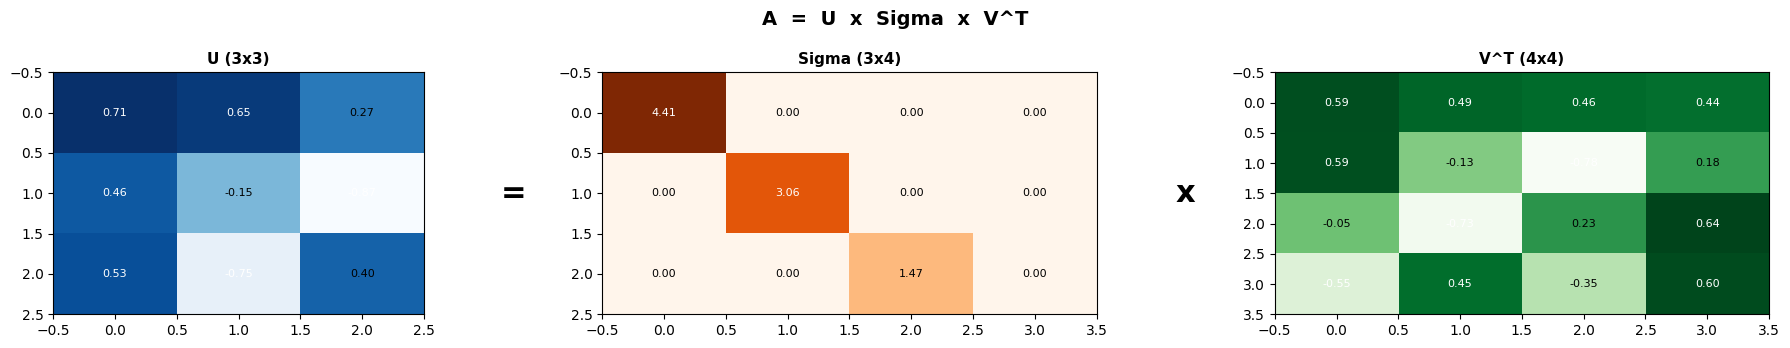

Sigma = [4.4097 3.0646 1.4707]
Reconstructs? True


In [ ]:
A_v = np.array([[3,1,0,2],[1,2,1,0],[0,1,3,1]])
U_v, s_v, Vt_v = np.linalg.svd(A_v)
S_v = np.zeros(A_v.shape); np.fill_diagonal(S_v, s_v)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5),
    gridspec_kw={'width_ratios': [3, 0.5, 4, 0.5, 4]})
items = [(U_v, f'U ({U_v.shape[0]}x{U_v.shape[1]})', 'Blues'),
         (None, '=', None),
         (S_v, f'Sigma ({S_v.shape[0]}x{S_v.shape[1]})', 'Oranges'),
         (None, 'x', None),
         (Vt_v, f'V^T ({Vt_v.shape[0]}x{Vt_v.shape[1]})', 'Greens')]
for ax, (mat, title, cmap) in zip(axes, items):
    if mat is None:
        ax.text(0.5, 0.5, title, ha='center', va='center', fontsize=22, fontweight='bold')
        ax.axis('off')
    else:
        ax.imshow(mat, cmap=cmap, aspect='auto')
        ax.set_title(title, fontsize=11, fontweight='bold')
        for r in range(mat.shape[0]):
            for c in range(mat.shape[1]):
                v = mat[r,c]
                clr = 'white' if abs(v) > 0.5*np.abs(mat).max() else 'black'
                ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=8, color=clr)
plt.suptitle('A  =  U  x  Sigma  x  V^T', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Sigma = {s_v.round(4)}")
print(f"Reconstructs? {np.allclose(A_v, U_v @ S_v @ Vt_v)}")

### The SVD at a Glance

The heatmap shows the three factors for a $3 \times 4$ matrix. $\mathbf{U}$ and $\mathbf{V}^T$ are dense orthogonal matrices (directions). $\boldsymbol{\Sigma}$ is sparse with all importance concentrated on its diagonal. The product perfectly reconstructs the original.

---
## Summary

$$\mathbf{A}_{M \times N} = \mathbf{U}_{M \times M} \, \boldsymbol{\Sigma}_{M \times N} \, \mathbf{V}^T_{N \times N}$$

| Factor | Properties | Reveals |
|:---|:---|:---|
| $\mathbf{U}$ | Orthogonal ($M \times M$) | Column space + left-null space |
| $\boldsymbol{\Sigma}$ | Diagonal, non-negative, sorted | Rank, variance, condition number |
| $\mathbf{V}^T$ | Orthogonal ($N \times N$) | Row space + null space |

**Key formulas:**

$$\text{rank} = \#\{\sigma_i > 0\} \qquad \kappa = \sigma_{\max}/\sigma_{\min} \qquad \mathbf{A}^+ = \mathbf{V}\boldsymbol{\Sigma}^+\mathbf{U}^T$$

$$\mathbf{A}\mathbf{A}^T = \mathbf{U}\boldsymbol{\Sigma}^2\mathbf{U}^T \qquad \mathbf{A}^T\mathbf{A} = \mathbf{V}\boldsymbol{\Sigma}^2\mathbf{V}^T \qquad \mathbf{A} = \sum_{i=1}^r \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

**Connections across the book:**

- **Chapter 4:** SVD provides orthonormal bases for all four subspaces
- **Chapter 6:** Rank = number of nonzero singular values
- **Chapter 12:** Pseudoinverse (least squares) is computed via SVD
- **Chapter 13:** SVD generalizes eigendecomposition to non-square matrices
- **Chapter 15:** PCA, LDA, compression, denoising all use SVD